# Zendo 交互式游戏测试平台 - Surprise Driven Strategy

这个 Notebook 实现了一个全新的 Agent 策略 —— **Surprise Driven Agent (SDA)**。
该 Agent 与之前的 Average Confidence Agent 在以下三个核心方面有着截然不同的机制：

1.  **记忆驱动的演化起点 (Memory-Driven Initialization)**：
    *   Ising 链不再从随机状态启动，而是继承上一轮的“内部模型”。
    *   我们将上一轮的概率性信心（Confidence）通过随机化过程塌缩为确定性的自旋构型，作为新一轮 MCMC 的起点。
2.  **反馈驱动的温控机制 (Feedback-Driven Temperature)**：
    *   引入 **Surprise (惊奇度)** 概念：$S_t = \frac{1}{2} |y_t - \bar{h}_t(x_t)|$。
    *   如果现实符合预期 ($S_t \approx 0$)，系统保持低温微调。
    *   如果现实打脸 ($S_t \approx 1$)，系统温度飙升 ($T_{start} \uparrow$)，导致内部模型“融化”并重新退火搜索。
3.  **动态激进策略 (Dynamic Aggressiveness)**：
    *   引入 **Aggressiveness (激进指数)** $A_t$，根据历史反馈动态调整。
    *   **激进模式 (Aggresive)**：主动挑战模型最自信的正例，寻求“证伪”带来的最大 Surprise。
    *   **保守模式 (Conservative)**：受挫后退回安全区，寻找离锚点最近且模型认为是正例的公案，寻求“证实”以恢复信心。


In [1]:
import os
import random  
import torch   
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from numba import jit

# 导入游戏核心模块
from game import RuleEngine
from world import KoanAtlas
from physics import IsingModel
from dynamics import DPP, SlowLearner
from config import Config

# --- 全局配置 ---
GAME_ID = 6  # 选择游戏规则 (1-9)
SEED = 4242

@jit(nopython=True)
def _set_numba_seed(value):
    np.random.seed(value)

def seed_everything(seed=42):
    """
    全方位设置随机种子，确保实验可复现
    涵盖: Python, NumPy, PyTorch, Numba
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    # 设置 Numba 的随机种子
    _set_numba_seed(seed)

# 初始化随机种子
seed_everything(SEED)

# 绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ 模块导入完成，随机种子已锁定为 {SEED}")

✅ 模块导入完成，随机种子已锁定为 4242


In [2]:
# ==========================================
# 重新实现 Glauber Dynamics 内核
# (为了支持自定义的退火温度 Schedule 并具备监控功能)
# ==========================================

@jit(nopython=True)
def compute_energy_numba(spins, J_matrix, h_field):
    n = len(spins)
    j_term = 0.0
    for i in range(n):
        row_sum = 0.0
        row = J_matrix[i]
        for j in range(n):
            row_sum += row[j] * spins[j]
        j_term += spins[i] * row_sum
    h_term = np.dot(h_field, spins)
    return -0.5 * j_term - h_term

@jit(nopython=True)
def glauber_core_custom(spins, J_matrix, h_field, steps, betas):
    """
    修改版的 Glauber 动力学核心，接受自定义的 betas 序列
    返回: (final_spins, energy_history, acceptance_history)
    """
    n_koans = len(spins)
    current_spins = spins.copy()
    
    # --- 监控配置 ---
    record_interval = 250 # 采样间隔：5127*20 ~ 100k steps -> 400 points
    n_records = steps // record_interval
    energy_history = np.zeros(n_records)
    accept_history = np.zeros(n_records)
    
    current_energy = compute_energy_numba(current_spins, J_matrix, h_field)
    accept_count = 0.0
    
    for step in range(steps):
        # 1. 随机选择翻转节点
        idx = np.random.randint(0, n_koans)
        
        # 2. 计算能量差
        # interaction = sum(J_ij * s_j)
        interaction = 0.0
        row = J_matrix[idx]
        for j in range(n_koans):
            interaction += row[j] * current_spins[j]
            
        local_field = interaction + h_field[idx]
        
        # Delta E = 2 * s_i * h_local
        delta_E = 2.0 * current_spins[idx] * local_field
        
        # 3. 接受准则 (使用当前步的 beta)
        beta = betas[step]
        # 避免溢出
        if beta * delta_E > 20.0:
            prob = 0.0
        elif beta * delta_E < -20.0:
            prob = 1.0
        else:
            prob = 1.0 / (1.0 + np.exp(beta * delta_E))
        
        if np.random.rand() < prob:
            current_spins[idx] *= -1.0
            current_energy += delta_E
            accept_count += 1.0
            
        # 4. 记录数据
        if (step + 1) % record_interval == 0:
            rec_idx = (step + 1) // record_interval - 1
            if rec_idx < n_records:
                energy_history[rec_idx] = current_energy
                accept_history[rec_idx] = accept_count / record_interval
                accept_count = 0.0
            
    return current_spins, energy_history, accept_history

class CustomFastSolver:
    """支持自定义起始温度和初态的求解器"""
    def run_annealing(self, ising_model, initial_spins, start_temp, end_temp, steps):
        # 生成温度序列: 指数衰减
        # T(t) = T_start * (T_end / T_start) ^ (t / steps)
        t_array = np.arange(steps)
        temperatures = start_temp * (end_temp / start_temp) ** (t_array / max(1, steps - 1))
        betas = 1.0 / temperatures
        
        return glauber_core_custom(
            initial_spins,
            ising_model.J_matrix,
            ising_model.h_field,
            steps,
            betas
        )

print("✅ CustomFastSolver (Monitor Enhanced) 已定义")

✅ CustomFastSolver (Monitor Enhanced) 已定义


In [3]:
# ==========================================
# Surprise Driven Agent (SDA) 核心类
# ==========================================

class SurpriseDrivenAgent:
    def __init__(self, game_id):
        self.atlas = KoanAtlas()
        self.rule_engine = RuleEngine(self.atlas)
        self.physics = IsingModel(self.atlas.num_koans)
        self.solver = CustomFastSolver()
        self.dpp = DPP()
        self.learner = SlowLearner(self.atlas)
        self.game_id = game_id
        
        # 获取 Ground Truth
        self.gt_vector, self.rule_name = self.rule_engine.get_ground_truth_vector(game_id - 1)
        self.gt_magnetization = np.mean(self.gt_vector)
        
        # 状态变量
        self.pos_indices = np.where(self.gt_vector > 0)[0]
        self.neg_indices = np.where(self.gt_vector < 0)[0]
        self.known_pos = []
        self.known_neg = []
        
        # 初始锚点 (随机选取一个正例)
        start_node = np.random.choice(self.pos_indices)
        self.known_pos.append(start_node)
        self.current_anchor = start_node
        
        # 内部模型 (初始为全0或随机)
        # 范围 [-1, 1], 0 表示完全不确定
        self.internal_model = np.zeros(self.atlas.num_koans) 
        
        # 激进指数 A_t (初始设定为 0.75, 假设初始比较自信)
        self.aggressiveness = 0.75
        self.gamma = 0.5
        
        # 记录器
        self.history = {
            "round": [],
            "aggressiveness": [],
            "surprise": [],
            "start_temp": [],
            "strategy": [], # 'Aggressive' or 'Conservative'
            "accuracy": [],
            "magnetization": [],
            "gt_magnetization": self.gt_magnetization,
            "test_koan": [],
            "test_result": [],
            "internal_models": [],   # 存储每轮的信心分布
            "hard_hypotheses": [],   # 存储每轮的硬决策样本
            "gt_vector": self.gt_vector, # 存储GT以便绘图
            "attention": [],          # 存储每轮的注意力权重
            "chains_evolution": []    # [New] 存储每轮20条链的演化数据 (Energy, Accept, etc.)
        }
        
        print(f"🤖 Agent 初始化完成. 初始锚点: #{start_node}")

    def _generate_deterministic_start(self, confidence_map):
        """
        核心机制 1: 记忆驱动的起点
        将概率性的信心分布 ([-1, 1]) 塌缩为确定性的自旋构型 ({-1, 1})
        """
        rand_vals = np.random.uniform(-1, 1, size=len(confidence_map))
        # 规则: 
        # 如果 rand [-1, 1] <= confidence, 则为 +1 (自旋向上)
        spins = np.where(rand_vals <= confidence_map, 1.0, -1.0).astype(np.float32)
        return spins

    def _select_query_koan(self, attention, round_num):
        """
        核心机制 2 & 3: 动态激进策略选择
        """
        # 1. 确定候选池 (未检验的公案)
        known_set = set(self.known_pos) | set(self.known_neg)
        unknown_mask = np.ones(self.atlas.num_koans, dtype=bool)
        unknown_mask[list(known_set)] = False
        candidate_indices = np.where(unknown_mask)[0]
        
        # 2. 决定策略模式: 掷骰子
        # 以 A_t 的概率激进，1 - A_t 的概率保守
        is_aggressive = np.random.rand() < self.aggressiveness
        
        selected_idx = -1
        strategy_name = ""
        dist_val = 0.0
        
        predictions = self.internal_model[candidate_indices]
        
        if is_aggressive:
            strategy_name = "Aggressive"
            # 激进策略：P(x) \propto exp(beta * h(x))
            # 倾向于选择模型极度确信为正 (h -> +1) 的公案进行"证伪"
            beta = 2.0
            # 加上一个很小的噪声防止全0
            logits = beta * predictions
            logits -= np.max(logits) # 防止溢出
            probs = np.exp(logits)
            probs /= np.sum(probs)
            
            selected_idx = np.random.choice(candidate_indices, p=probs)
            
        else:
            strategy_name = "Conservative"
            # 保守策略：min [ D(x, anchor) - lambda * h(x) ]
            # 寻找离曾经验证过的正例(锚点)最近，且模型倾向于认为是正例的公案
            lambda_param = 0.1
            
            # 计算距离 (基于当前注意力)
            # 仅计算 candidate 到 anchor 的距离
            # dist_basis shape: (N, N, 4) -> 取 slice (M, 4)
            # anchor index is scalar
            d_vecs = self.atlas.dist_basis[candidate_indices, self.current_anchor, :] # (M, 4)
            d_weighted = np.dot(d_vecs, attention) # (M,)
            
            scores = d_weighted - lambda_param * predictions
            best_local_idx = np.argmin(scores)
            selected_idx = candidate_indices[best_local_idx]
            dist_val = d_weighted[best_local_idx]
            
        return selected_idx, strategy_name, dist_val

    def run(self, max_rounds=7):
        print(f"\n🎮 开始游戏: {self.rule_name}")
        current_attention = Config.INIT_ATTENTION.copy()
        
        # 初始温度状态
        T_base = 0.6
        delta_T = 2.0
        T_start = 2.0 # 第一轮默认从较高温开始
        last_surprise = 1.0 # 假装第一轮很 Surprise，以便进行充分探索
        
        for r in range(max_rounds):
            print(f"\n🔄 Round {r+1} | A_t={self.aggressiveness:.2f} | Last_S={last_surprise:.2f} | T_start={T_start:.2f}")
            
            # 1. 更新物理场
            dist_mat = self.atlas.get_weighted_distance_matrix(current_attention)
            self.physics.update_couplings(dist_mat)
            self.physics.set_pinning_field(self.known_pos, self.known_neg, r)
            
            # 2. 生成假设 (20条链)
            # 核心: 初始构型继承自上一轮 Internal Model
            chains = []
            mcmc_steps = self.atlas.num_koans * 20
            
            # [New] 用于存储当前轮次所有链的演化数据
            round_chains_evo = {'energy': [], 'accept': [], 'start_temp': T_start, 'end_temp': T_base, 'steps': mcmc_steps}
            
            for _ in range(Config.NUM_CHAINS):
                # 如果是第一轮，internal_model 还是全0，相当于随机
                init_spins = self._generate_deterministic_start(self.internal_model)
                final_spins, e_hist, acc_hist = self.solver.run_annealing(
                    self.physics, 
                    init_spins, 
                    start_temp=T_start, 
                    end_temp=T_base, 
                    steps=mcmc_steps
                )
                chains.append(final_spins)
                # Store monitored data
                round_chains_evo['energy'].append(e_hist)
                round_chains_evo['accept'].append(acc_hist)

            # Store to history
            self.history["chains_evolution"].append(round_chains_evo)
            
            # 3. DPP 融合与内部模型更新
            selected_indices, _ = self.dpp.select_subset(chains, self.physics)
            # 选10条
            subset = [chains[i] for i in selected_indices]
            while len(subset) < 10:
                subset.append(chains[np.random.randint(len(chains))])
            
            # 更新内部模型 (Confidence)
            self.internal_model = np.mean(np.stack(subset), axis=0)
            
            # 生成用于可视化的硬假设样本
            vis_hard_hyp = self._generate_deterministic_start(self.internal_model)
            
            # 计算当前准确率 (仅用于上帝视角观察)
            # 将信心转化为硬决策来算 Acc
            decision = np.sign(self.internal_model)
            acc = np.mean(decision == self.gt_vector)
            mag = np.mean(decision)
            
            # 4. 主动检验
            test_idx, strat_name, dist_val = self._select_query_koan(current_attention, r)
            
            # 获取反馈
            real_val = self.gt_vector[test_idx]
            is_pos = (real_val > 0)
            prediction = self.internal_model[test_idx]
            
            # 记录结果
            if is_pos:
                self.known_pos.append(test_idx)
                # 更新锚点: 当且仅当找到新的正例时，更新锚点
                self.current_anchor = test_idx
                feedback_val = 1.0
                res_str = "✅ Pass"
            else:
                self.known_neg.append(test_idx)
                feedback_val = -1.0
                res_str = "❌ Fail"
            
            print(f"   🧪 [策略: {strat_name}] 检验 #{test_idx} (预测: {prediction:.2f}) -> {res_str}")
            if strat_name == "Conservative":
                print(f"      📏 距离锚点 (#{self.current_anchor}) 距离 D = {dist_val:.4f}")
            
            # 5. 计算 Surprise 和更新参数
            # Surprise $S_t = 0.5 * |y - h|$
            current_surprise = 0.5 * np.abs(feedback_val - prediction)
            
            # 更新激进指数 $A_t$
            # $\mathbb{I}(y_{t-1} = +1)$ -> if feedback_val == 1.0 then 1 else 0
            reward = 1.0 if feedback_val > 0 else 0.0
            new_aggressiveness = self.gamma * self.aggressiveness + (1 - self.gamma) * reward
            
            # 记录历史
            self.history["round"].append(r+1)
            self.history["aggressiveness"].append(self.aggressiveness)
            self.history["surprise"].append(current_surprise)
            self.history["start_temp"].append(T_start)
            self.history["strategy"].append(strat_name)
            self.history["accuracy"].append(acc)
            self.history["magnetization"].append(mag)
            self.history["test_koan"].append(test_idx)
            self.history["test_result"].append(feedback_val)
            self.history["internal_models"].append(self.internal_model.copy())
            self.history["hard_hypotheses"].append(vis_hard_hyp.copy())
            self.history["attention"].append(current_attention.copy()) # Record Attention
            
            # 为下一轮做准备
            self.aggressiveness = new_aggressiveness
            last_surprise = current_surprise
            
            # 计算下一轮的起始温度
            # T_{t+1} = T_base + Delta T * S_t
            T_start = T_base + delta_T * current_surprise
            
            # 6. 慢动力学更新 (注意力)
            current_attention = self.learner.update_attention(current_attention, self.known_pos, self.known_neg)

        return self.history

print("✅ SurpriseDrivenAgent (Evolution Tracking) 类定义完成")

✅ SurpriseDrivenAgent (Evolution Tracking) 类定义完成


In [4]:
# ==========================================
# 运行实验
# ==========================================

# ⚠️ 确保每次运行前重置种子，以保证实验结果完全可重复
seed_everything(SEED)

# 实例化并运行
agent = SurpriseDrivenAgent(GAME_ID)
history = agent.run(max_rounds=7)

print("\n🎉 游戏结束，准备进行可视化分析...")

正在初始化 Zendo 公案图册 (Koan Atlas)...
图册构建完成。已索引 5127 个公案。
特征张量形状: (5127, 3, 7)
结构张量形状: (5127, 3, 3)
质量张量形状: (5127, 3)
正在加载距离张量: data/dist_fused_5127.npy ...
距离张量已加载。Shape: (5127, 5127, 4)

📜 正在编译规则 [6/9]: 红者最大 ...
🤖 Agent 初始化完成. 初始锚点: #3754

🎮 开始游戏: 红者最大

🔄 Round 1 | A_t=0.75 | Last_S=1.00 | T_start=2.00
   🧪 [策略: Aggressive] 检验 #348 (预测: 0.60) -> ❌ Fail

🔄 Round 2 | A_t=0.38 | Last_S=0.80 | T_start=2.20
   🧪 [策略: Conservative] 检验 #3622 (预测: 0.60) -> ✅ Pass
      📏 距离锚点 (#3622) 距离 D = 0.2133

🔄 Round 3 | A_t=0.69 | Last_S=0.20 | T_start=1.00
   🧪 [策略: Aggressive] 检验 #1000 (预测: 0.80) -> ❌ Fail

🔄 Round 4 | A_t=0.34 | Last_S=0.90 | T_start=2.40
   🧪 [策略: Conservative] 检验 #3628 (预测: 0.80) -> ❌ Fail
      📏 距离锚点 (#3622) 距离 D = 0.2041

🔄 Round 5 | A_t=0.17 | Last_S=0.90 | T_start=2.40
   🧪 [策略: Conservative] 检验 #3625 (预测: 0.40) -> ❌ Fail
      📏 距离锚点 (#3622) 距离 D = 0.2155

🔄 Round 6 | A_t=0.09 | Last_S=0.70 | T_start=2.00
   🧪 [策略: Conservative] 检验 #3800 (预测: 0.40) -> ✅ Pass
      📏 距离锚点 (#3800

/var/folders/53/0d8k5xdx1dl0jpxkb2t64s5h0000gn/T/ipykernel_97296/1242617814.py:112: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) SimHei.
  plt.tight_layout()
/Users/stoicismpoint/Desktop/anaconda/anaconda3/envs/zendo/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


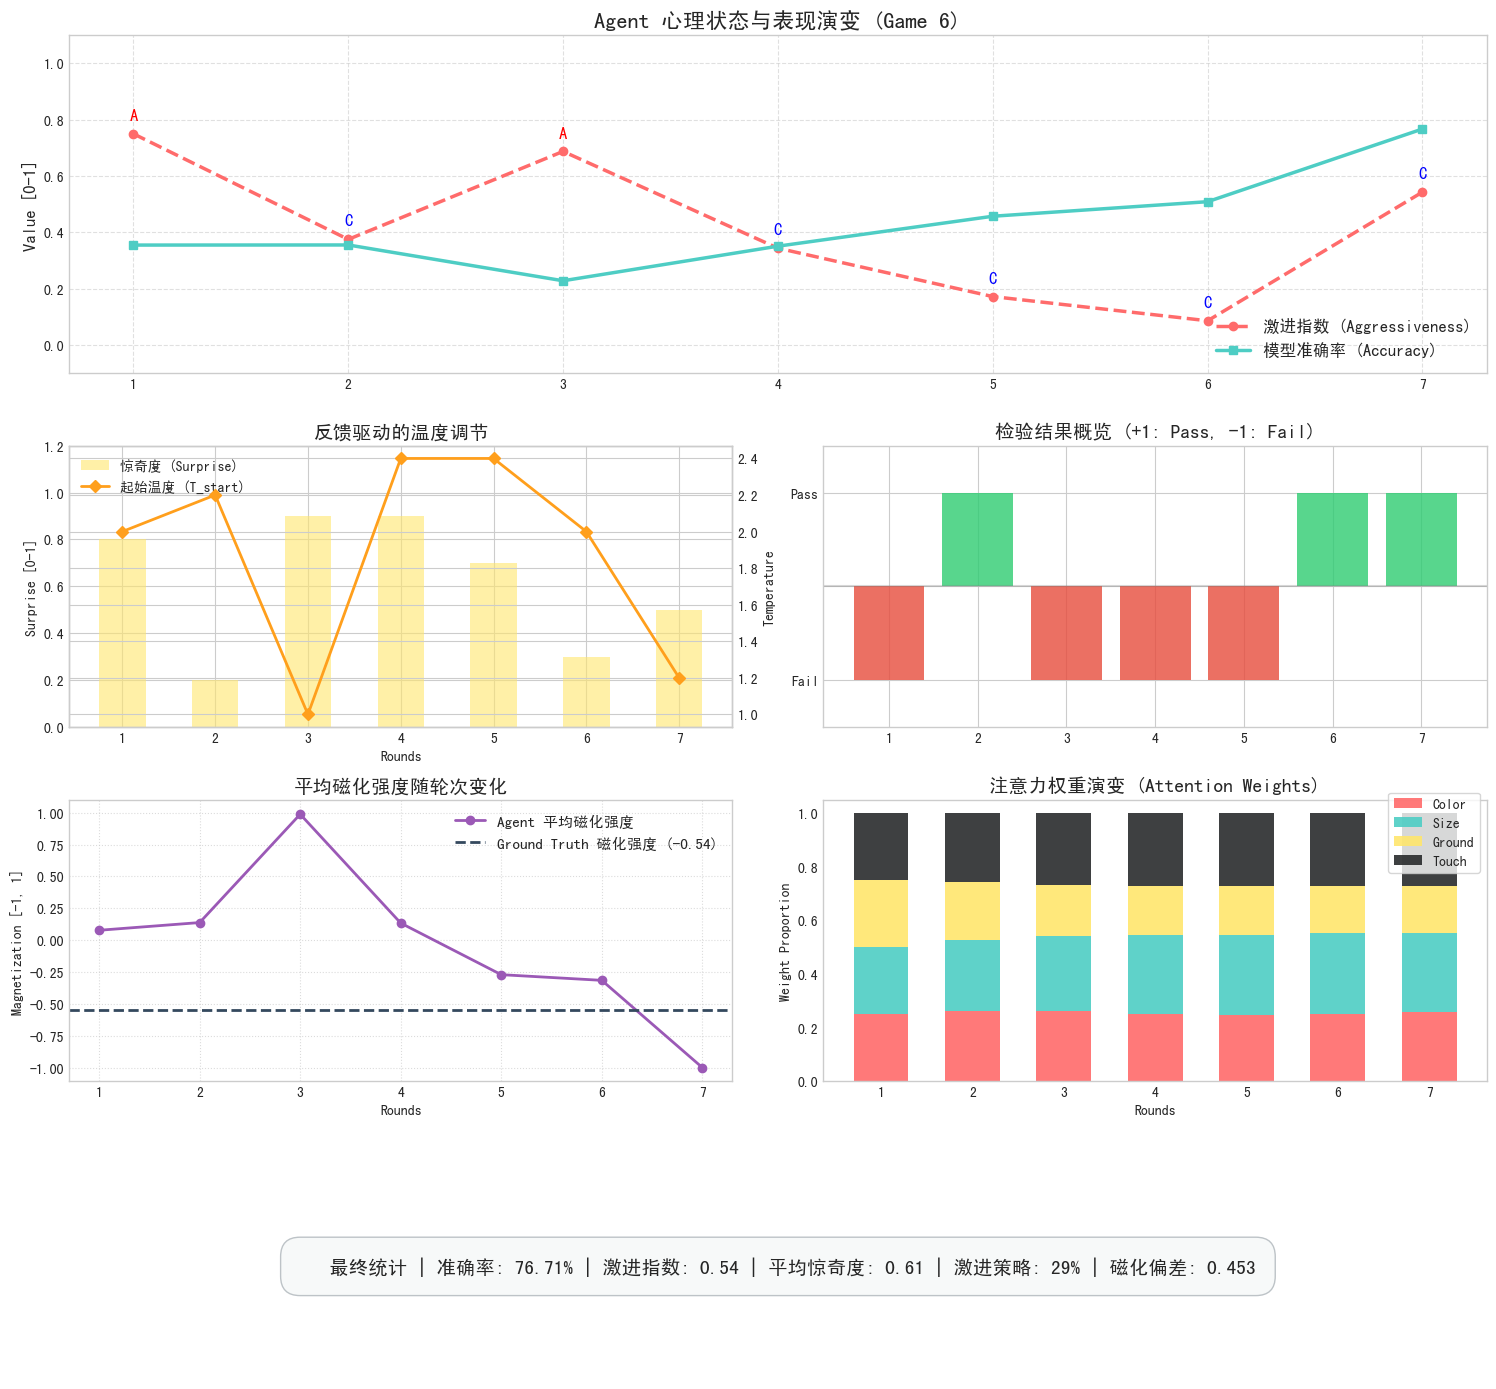

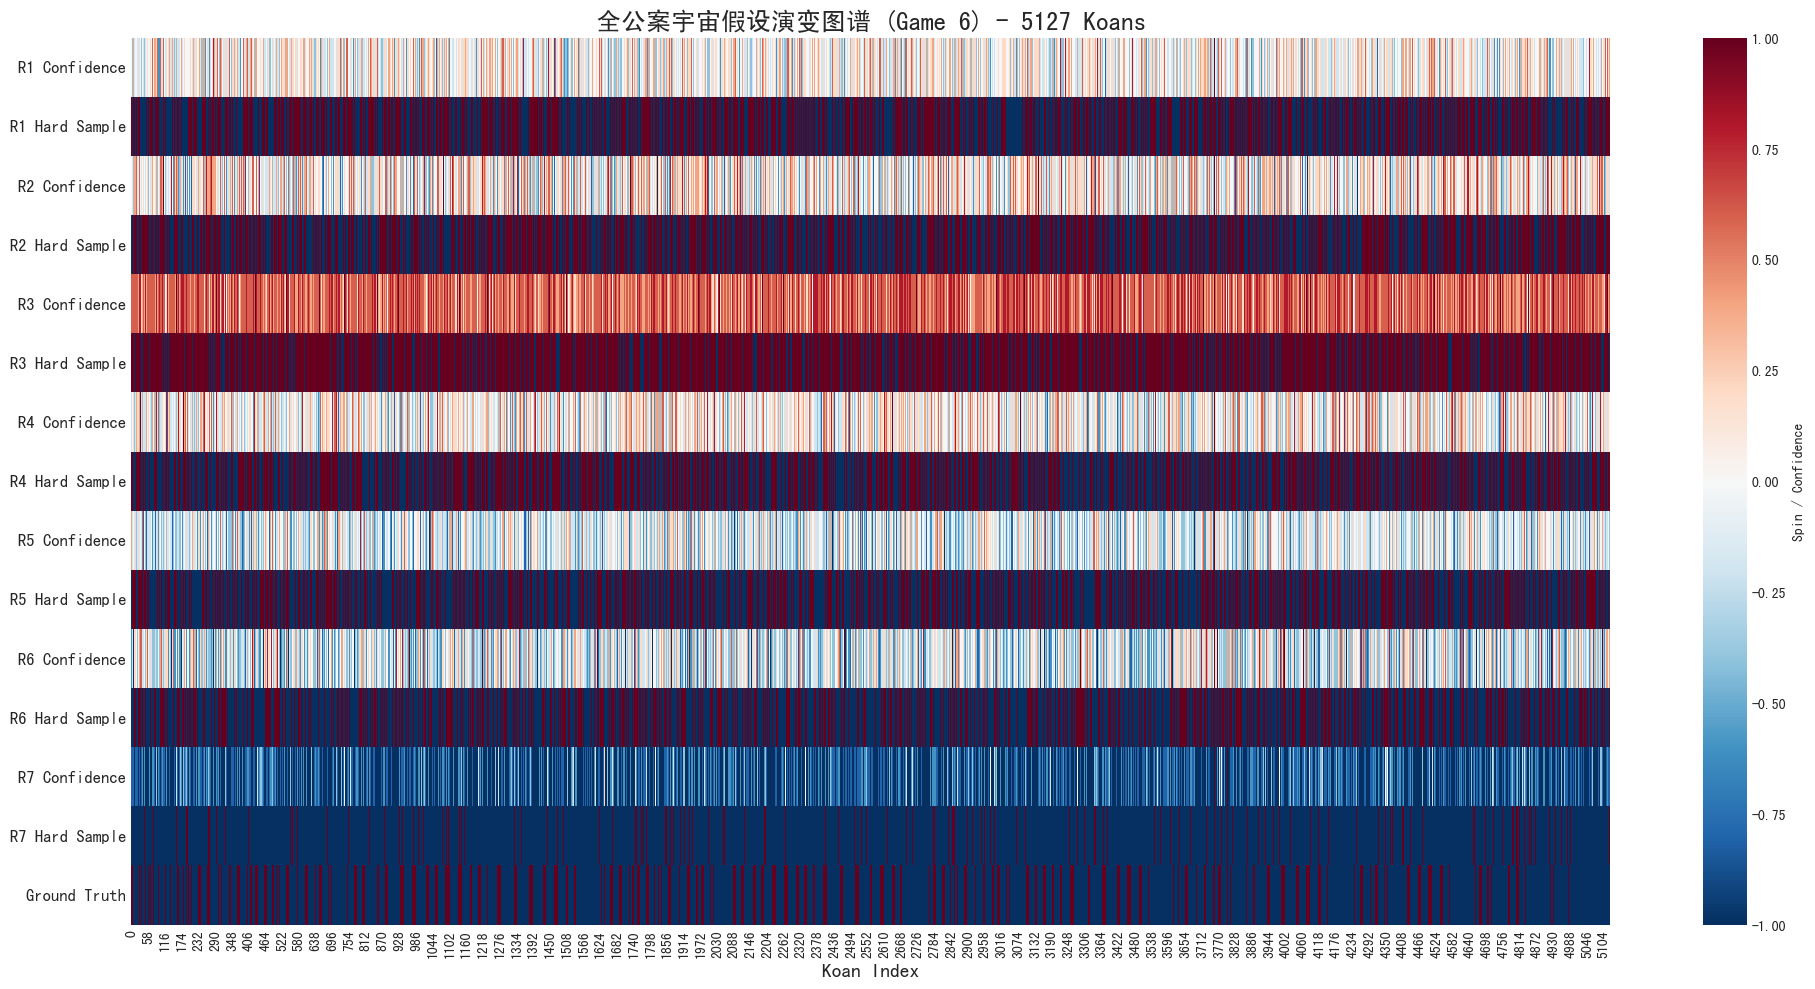

In [5]:
# ==========================================
# 综合可视化 Dashboard
# ==========================================

def plot_dashboard(hist):
    rounds = hist["round"]
    gt_mag = hist["gt_magnetization"]
    att_history = np.array(hist.get("attention", [])) # (Rounds, 4)
    
    fig = plt.figure(figsize=(15, 14))
    gs = fig.add_gridspec(4, 2, height_ratios=[1.2, 1, 1, 0.8])

    # 1. 核心指标演变 (Aggressiveness & Accuracy)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(rounds, hist["aggressiveness"], 'o--', color='#FF6B6B', linewidth=2.5, label='激进指数 (Aggressiveness)')
    ax1.plot(rounds, hist["accuracy"], 's-', color='#4ECDC4', linewidth=2.5, label='模型准确率 (Accuracy)')
    
    # 标注策略选择
    for i, strat in enumerate(hist["strategy"]):
        y_val = hist["aggressiveness"][i]
        marker = '★' if strat == 'Aggressive' else '●'
        color = 'red' if strat == 'Aggressive' else 'blue'
        ax1.annotate(strat[0], (rounds[i], y_val), xytext=(0, 10), textcoords='offset points', 
                     ha='center', color=color, fontweight='bold', fontsize=12)

    ax1.set_title(f"Agent 心理状态与表现演变 (Game {GAME_ID})", fontsize=16)
    ax1.set_ylabel("Value [0-1]", fontsize=12)
    ax1.set_ylim(-0.1, 1.1)
    ax1.legend(fontsize=12, loc='lower right')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. 惊奇度驱动的温度控制 (Surprise & Temperature)
    ax2 = fig.add_subplot(gs[1, 0])
    ax2_r = ax2.twinx() # 双轴
    
    l1 = ax2.bar(rounds, hist["surprise"], color='#FFE66D', alpha=0.6, label='惊奇度 (Surprise)', width=0.5)
    l2 = ax2_r.plot(rounds, hist["start_temp"], 'D-', color='#FF9F1C', linewidth=2, label='起始温度 (T_start)')
    
    ax2.set_title("反馈驱动的温度调节", fontsize=14)
    ax2.set_xlabel("Rounds")
    ax2.set_ylabel("Surprise [0-1]")
    ax2_r.set_ylabel("Temperature")
    ax2.set_ylim(0, 1.2)
    
    lines = [l1, l2[0]]
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper left')

    # 3. 检验结果序列
    ax3 = fig.add_subplot(gs[1, 1])
    results = hist["test_result"]
    colors = ['#2ECC71' if r > 0 else '#E74C3C' for r in results]
    
    ax3.bar(rounds, results, color=colors, alpha=0.8)
    ax3.set_title("检验结果概览 (+1: Pass, -1: Fail)", fontsize=14)
    ax3.set_ylim(-1.5, 1.5)
    ax3.set_yticks([-1, 0, 1])
    ax3.set_yticklabels(['Fail', '', 'Pass'])
    ax3.axhline(0, color='gray', linestyle='-', alpha=0.3)
    
    # 4. 平均磁化强度演变
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(rounds, hist["magnetization"], 'o-', color='#9B59B6', linewidth=2, label='Agent 平均磁化强度')
    ax4.axhline(gt_mag, color='#34495E', linestyle='--', linewidth=2, label=f'Ground Truth 磁化强度 ({gt_mag:.2f})')
    
    ax4.set_title("平均磁化强度随轮次变化", fontsize=14)
    ax4.set_xlabel("Rounds")
    ax4.set_ylabel("Magnetization [-1, 1]")
    ax4.set_ylim(-1.1, 1.1)
    ax4.legend(fontsize=11)
    ax4.grid(True, linestyle=':', alpha=0.7)

    # 5. [New] 注意力权重演变 (Stacked Bar Chart)
    if len(att_history) > 0:
        ax5 = fig.add_subplot(gs[2, 1])
        
        # 归一化以防万一 (虽然应该是归一化的)
        row_sums = att_history.sum(axis=1)
        att_norm = att_history / row_sums[:, np.newaxis]
        
        labels = ['Color', 'Size', 'Ground', 'Touch']
        colors = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#292b2c']
        
        bottom = np.zeros(len(rounds))
        
        for i in range(4):
            ax5.bar(rounds, att_norm[:, i], bottom=bottom, label=labels[i], color=colors[i], alpha=0.9, width=0.6)
            bottom += att_norm[:, i]
            
        ax5.set_title("注意力权重演变 (Attention Weights)", fontsize=14)
        ax5.set_xlabel("Rounds")
        ax5.set_ylabel("Weight Proportion")
        ax5.set_ylim(0, 1.05)
        ax5.legend(loc='upper right', frameon=True, fontsize=10, bbox_to_anchor=(1.0, 1.05))
        ax5.grid(False) # Stacked bar 看起来不需要 grid
        
    # 6. 文本总结 (移动到最下方)
    ax6 = fig.add_subplot(gs[3, :])
    ax6.axis('off')
    
    summary_text = (
        f"📊 最终统计 | "
        f"准确率: {hist['accuracy'][-1]*100:.2f}% | "
        f"激进指数: {hist['aggressiveness'][-1]:.2f} | "
        f"平均惊奇度: {np.mean(hist['surprise']):.2f} | "
        f"激进策略: {hist['strategy'].count('Aggressive') / len(hist['strategy']) * 100:.0f}% | "
        f"磁化偏差: {abs(hist['magnetization'][-1] - gt_mag):.3f}"
    )
    ax6.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=14, 
             bbox=dict(boxstyle="round,pad=1", facecolor='#F7F9F9', edgecolor='#BDC3C7'))

    plt.tight_layout()
    plt.show()

def plot_hypothesis_evolution(hist):
    """
    绘制假设演变热力图：
    展示 内部模型(信心) vs 硬假设(随机化样本) vs Ground Truth
    """
    internal_models = hist['internal_models']
    hard_hypotheses = hist['hard_hypotheses']
    gt_vector = hist['gt_vector']
    rounds = hist['round']
    
    n_rounds = len(rounds)
    
    # 准备数据矩阵
    # 每一轮有两行: [Internal Model, Hard Hypothesis]
    # 最后加一行 GT
    # 为了美观，我们把所有数据 stack 起来
    
    # 构造绘图矩阵
    # 布局: 
    # Row 0: R1 Internal
    # Row 1: R1 Hard
    # Row 2: R2 Internal
    # Row 3: R2 Hard
    # ...
    # Row 2N: Ground Truth
    
    matrix_rows = []
    yticklabels = []
    
    for i, r in enumerate(rounds):
        matrix_rows.append(internal_models[i])
        yticklabels.append(f"R{r} Confidence")
        
        matrix_rows.append(hard_hypotheses[i])
        yticklabels.append(f"R{r} Hard Sample")
        
    matrix_rows.append(gt_vector)
    yticklabels.append("Ground Truth")
    
    # (2N+1, Num_Koans)
    data_matrix = np.stack(matrix_rows)
    
    # 绘图
    plt.figure(figsize=(20, 10))
    
    # 使用 seaborn heatmap
    # cmap: coolwarm (Blue=-1, Red=+1, White=0)
    sns.heatmap(data_matrix, cmap="RdBu_r", vmin=-1, vmax=1, cbar_kws={'label': 'Spin / Confidence'})
    
    plt.title(f"全公案宇宙假设演变图谱 (Game {GAME_ID}) - 5127 Koans", fontsize=18)
    plt.xlabel("Koan Index", fontsize=14)
    plt.yticks(np.arange(data_matrix.shape[0]) + 0.5, yticklabels, rotation=0, fontsize=12)
    
    # 标记正例和反例的分布情况 (可选)
    # 这里的 Koan Index 是自然排序的，可以直观看到正例分布
    
    plt.tight_layout()
    plt.show()

plot_dashboard(history)
plot_hypothesis_evolution(history)

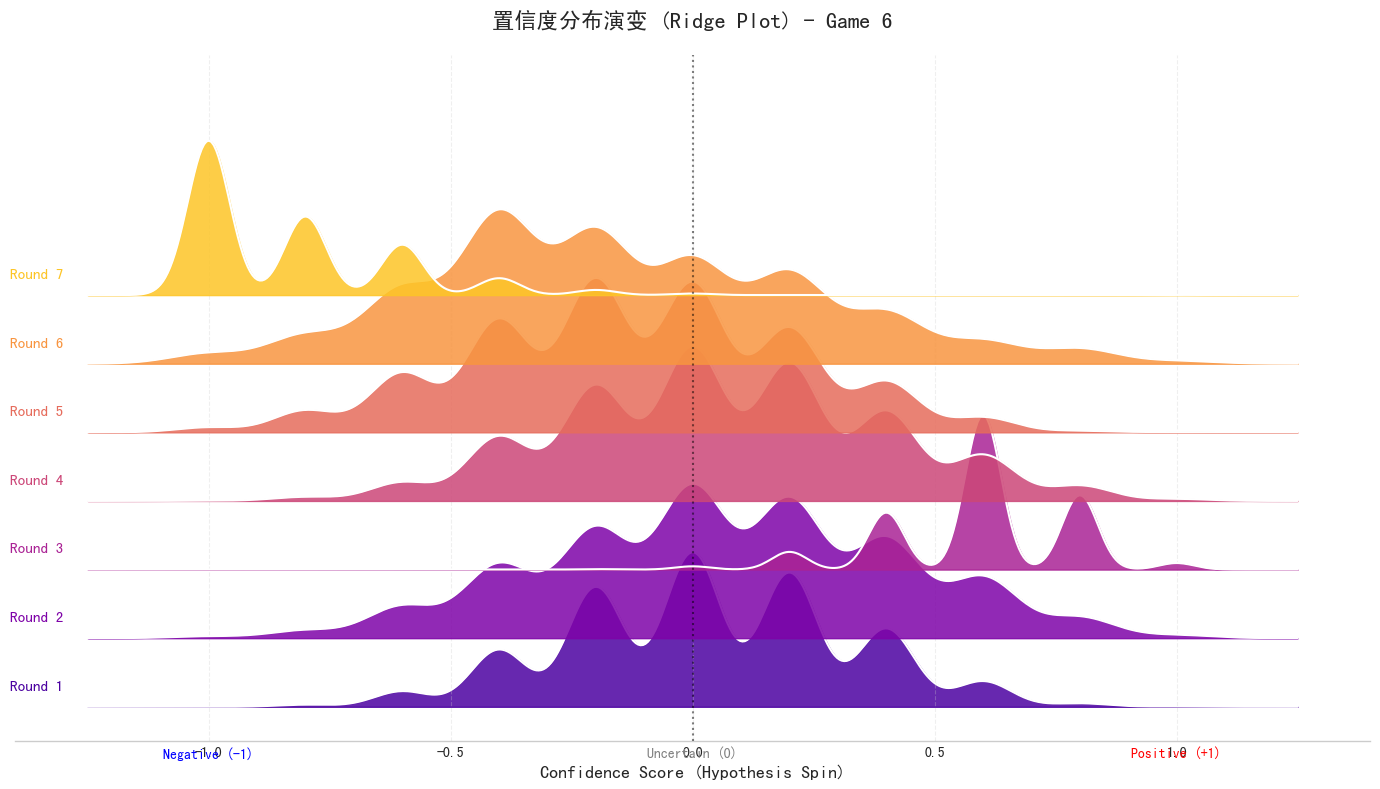

In [6]:
from scipy.stats import gaussian_kde

def plot_confidence_ridge(hist):
    """
    绘制 Ridge Plot (山脊图)，展示置信度分布随轮次的演变
    """
    internal_models = hist['internal_models']
    rounds = hist['round']
    n_rounds = len(rounds)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 生成 x 轴网格
    x = np.linspace(-1.25, 1.25, 500)
    
    # 颜色映射: 使用 coolwarm (Blue=Negative, Red=Positive) 
    # 或者用 viridis 区分轮次。为了配合 context，还是区分轮次比较好
    # 使用 seaborn 的 cubehelix 或 viridis
    palette = sns.color_palette("plasma", n_rounds)
    
    # 垂直偏移量
    spacing = 0.4
    
    # 正序绘制：Round 1 在最下方，后续轮次向上叠加并遮挡旧轮次
    # 这样产生"堆叠"效果
    for i in range(n_rounds):
        data = internal_models[i]
        
        # 计算 KDE
        try:
            # bw_method 控制平滑度
            kde = gaussian_kde(data, bw_method=0.2)
            y = kde(x)
            
            # 归一化高度，限制最大高度
            if y.max() > 0:
                y = y / y.max() * 0.9 
                
            base_y = i * spacing
            curr_color = palette[i]
            
            # 填充 (zorder 越高越靠前)
            # 我们希望新的轮次(i大)遮挡旧的轮次(i小)的顶部
            ax.fill_between(x, base_y, base_y + y, color=curr_color, alpha=0.85, zorder=i)
            
            # 轮廓线
            ax.plot(x, base_y + y, color='white', linewidth=1.5, zorder=i+0.1)
            
            # 轮次标签
            ax.text(-1.3, base_y + 0.1, f"Round {rounds[i]}", 
                    fontweight="bold", fontsize=11, ha="right", color=curr_color)
            
        except Exception as e:
            pass

    ax.set_yticks([])
    ax.set_xlabel("Confidence Score (Hypothesis Spin)", fontsize=13)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-0.2, n_rounds * spacing + 1.0)
    
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add Grid for x
    ax.xaxis.grid(True, linestyle='--', alpha=0.3)
    
    # Annotations
    ax.axvline(0, color='black', linestyle=':', alpha=0.5, zorder=999)
    ax.text(0, -0.3, "Uncertain (0)", ha='center', fontsize=10, color='gray')
    ax.text(1, -0.3, "Positive (+1)", ha='center', fontsize=10, color='red')
    ax.text(-1, -0.3, "Negative (-1)", ha='center', fontsize=10, color='blue')
    
    ax.set_title(f"置信度分布演变 (Ridge Plot) - Game {GAME_ID}", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# 调用绘图
plot_confidence_ridge(history)

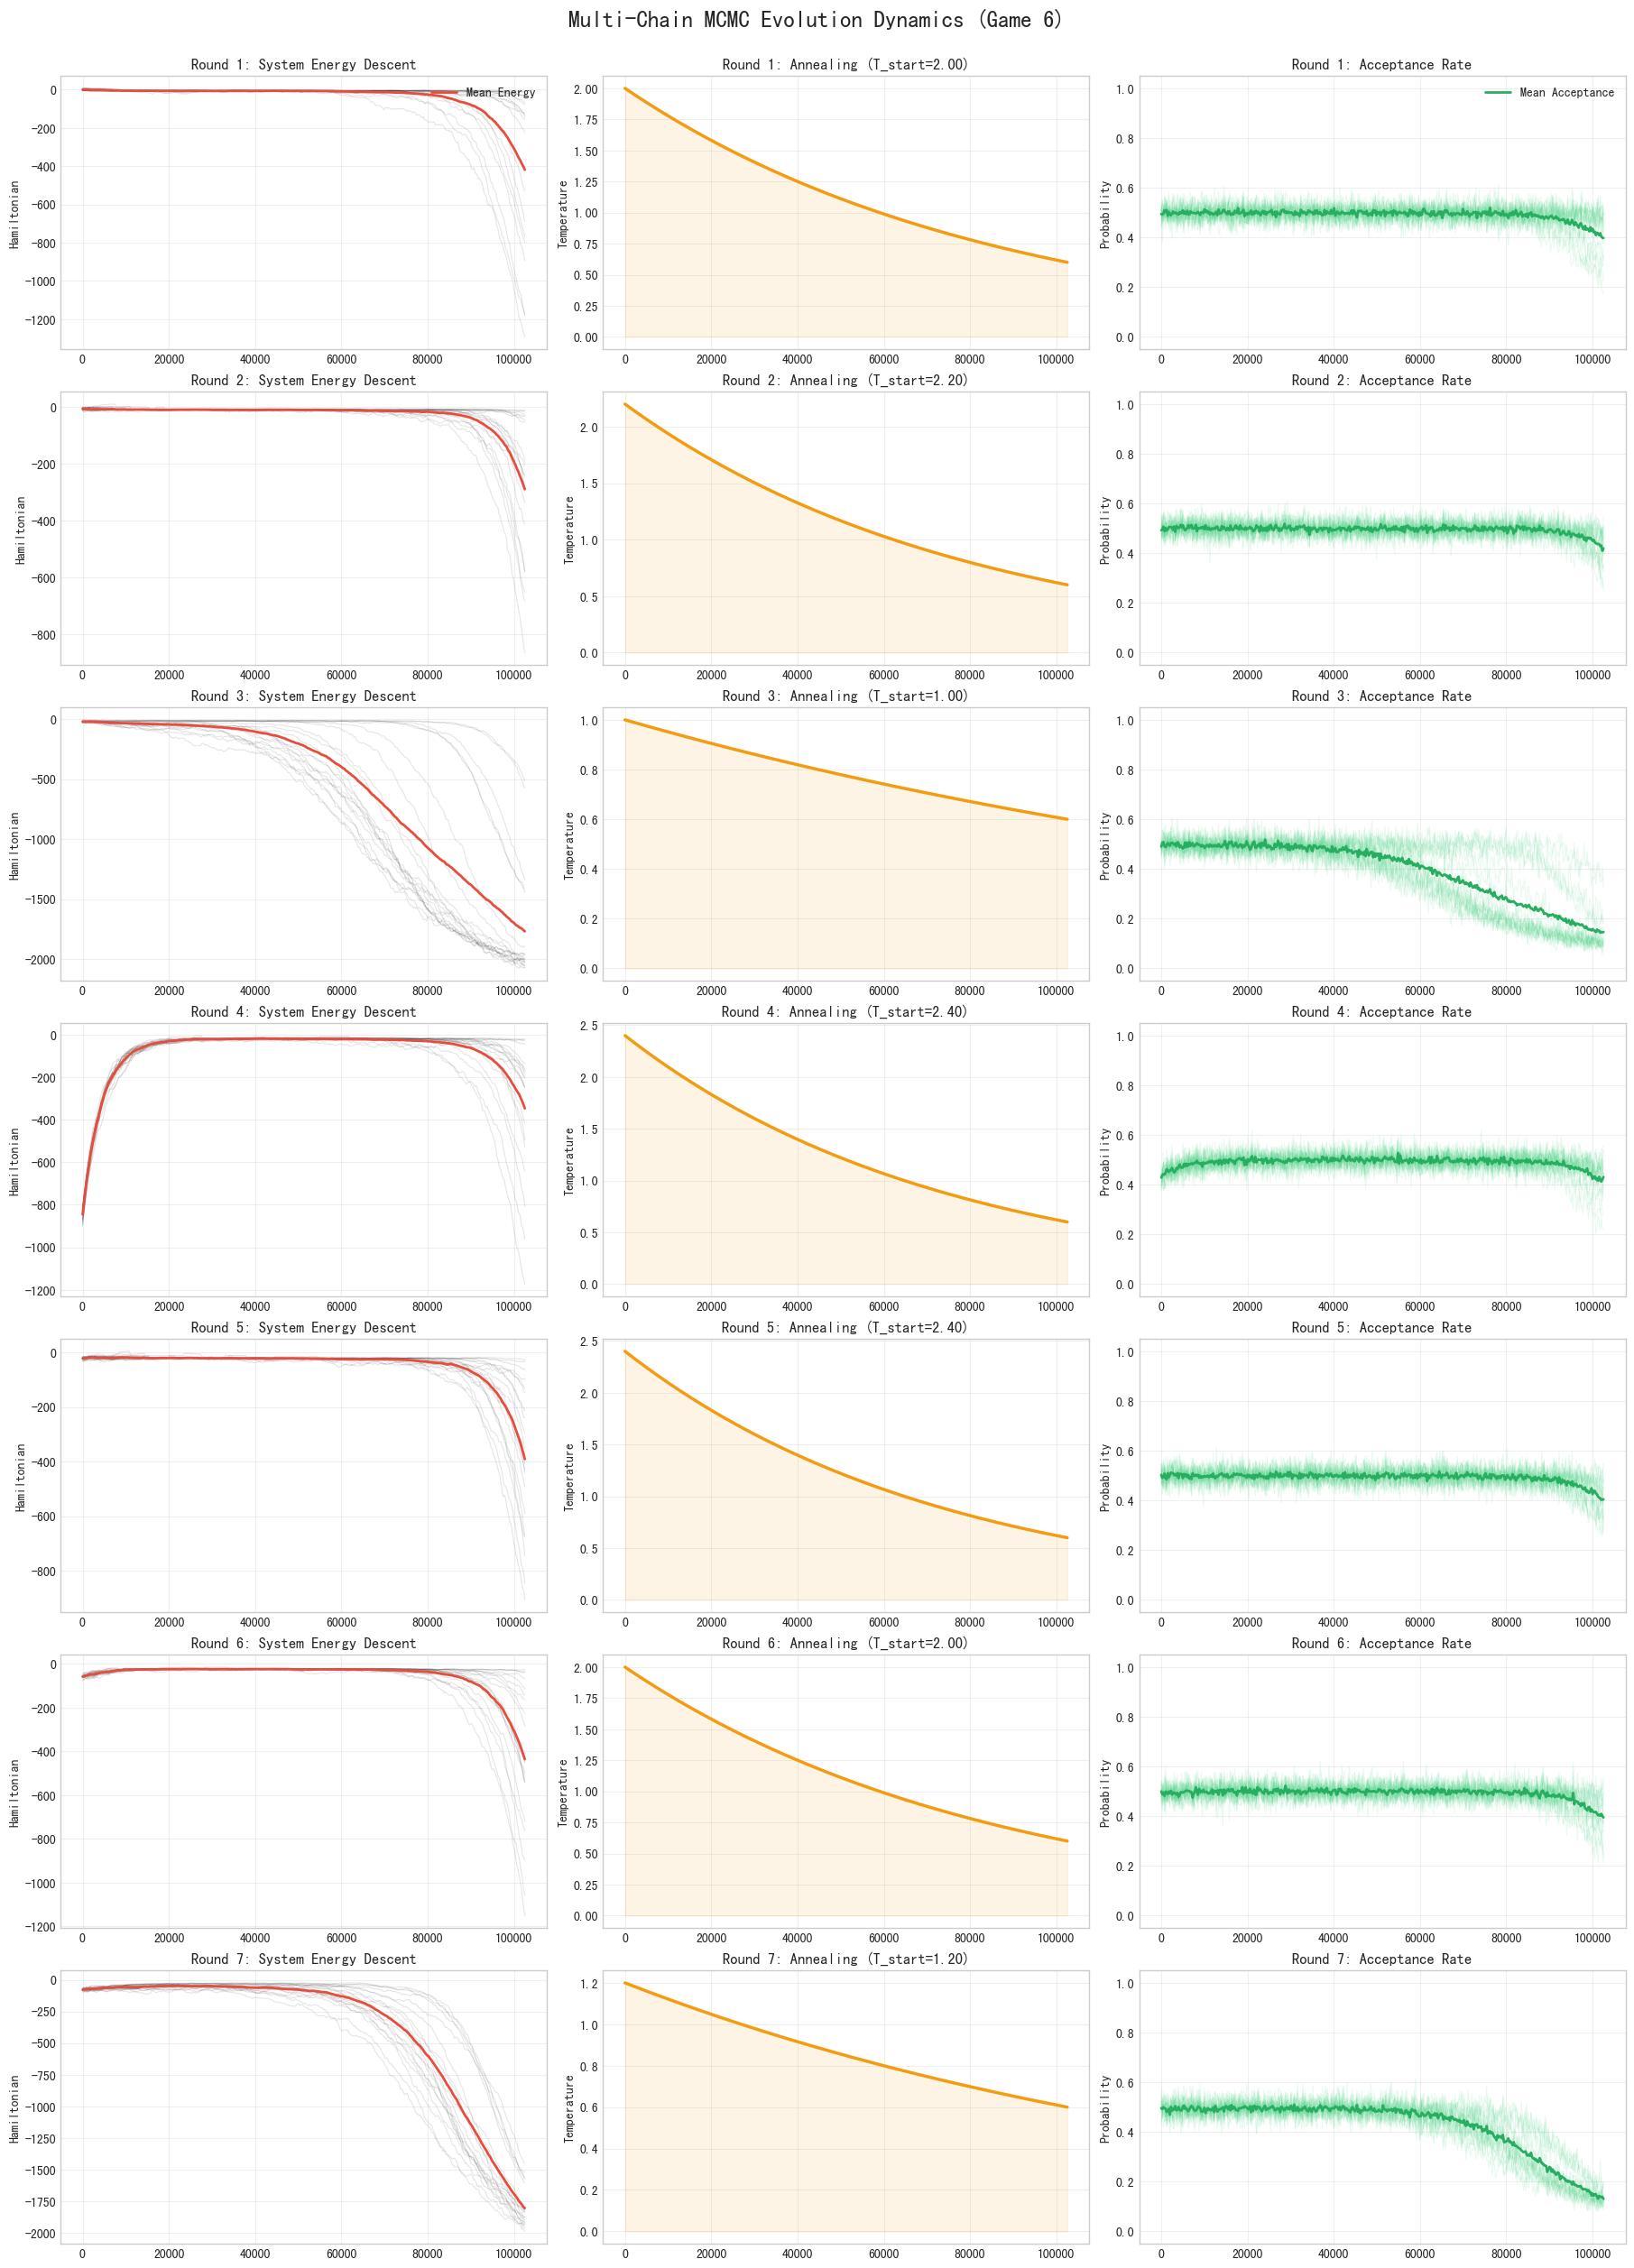

In [7]:
def plot_mcmc_evolution(hist):
    """
    绘制每轮 MCMC 的精细演化过程 (20条链的轨迹)
    包含: 系统能量、温度退火计划、接受率
    注意: 需要重新运行 Agent 以生成 'chains_evolution' 数据。
    """
    if "chains_evolution" not in hist:
        print("⚠️ 历史记录中未找到 'chains_evolution' 数据。请重新运行 Agent.run() 以采集演化数据。")
        return

    chains_data = hist["chains_evolution"]
    n_rounds = len(chains_data)
    
    # 创建大图: N 行 3 列
    # constrained_layout 用于自动调整子图间距
    fig, axes = plt.subplots(n_rounds, 3, figsize=(18, 3.5 * n_rounds), constrained_layout=True)
    
    # 如果只有一轮，axes 是一维数组，需要增加维度以便统一处理
    if n_rounds == 1:
        axes = np.array([axes])
        
    for r in range(n_rounds):
        data = chains_data[r]
        energies = data['energy'] # List of arrays
        accepts = data['accept']
        T_start = data['start_temp']
        T_end = data['end_temp']
        total_steps = data['steps']
        
        # X 轴数据 (采样点)
        if len(energies) == 0: continue
        n_points = len(energies[0])
        x_steps = np.linspace(0, total_steps, n_points)
        
        # Row axes
        ax_E = axes[r, 0]
        ax_T = axes[r, 1]
        ax_A = axes[r, 2]
        
        # 1. 能量演化 (System Energy)
        # 绘制所有链的阴影
        for i, E_traj in enumerate(energies):
            ax_E.plot(x_steps, E_traj, color='black', alpha=0.1, linewidth=0.8)
        # 绘制平均能量曲线
        mean_E = np.mean(np.stack(energies), axis=0)
        ax_E.plot(x_steps, mean_E, color='#E74C3C', linewidth=2, label='Mean Energy')
        
        ax_E.set_title(f"Round {r+1}: System Energy Descent", fontsize=12, fontweight='bold')
        ax_E.set_ylabel("Hamiltonian")
        ax_E.grid(True, alpha=0.3)
        if r == 0: ax_E.legend(loc='upper right') # 仅在第一行显示图例，避免遮挡
        
        # 2. 温度退火计划 (Temperature Schedule)
        # T(t) = T_start * (T_end / T_start) ^ (t / steps)
        t_cont = np.linspace(0, total_steps, 200)
        T_curve = T_start * (T_end / T_start) ** (t_cont / max(1, total_steps - 1))
        
        ax_T.plot(t_cont, T_curve, color='#F39C12', linewidth=2.5)
        ax_T.fill_between(t_cont, 0, T_curve, color='#F39C12', alpha=0.1)
        
        ax_T.set_title(f"Round {r+1}: Annealing (T_start={T_start:.2f})", fontsize=12, fontweight='bold')
        ax_T.set_ylabel("Temperature")
        ax_T.grid(True, alpha=0.3)
        
        # 3. 接受率变化 (Acceptance Rate)
        for A_traj in accepts:
            ax_A.plot(x_steps, A_traj, color='#2ECC71', alpha=0.1, linewidth=0.8)
        
        # 平滑平均接受率
        mean_A = np.mean(np.stack(accepts), axis=0)
        ax_A.plot(x_steps, mean_A, color='#27AE60', linewidth=2, label='Mean Acceptance')
        
        ax_A.set_title(f"Round {r+1}: Acceptance Rate", fontsize=12, fontweight='bold')
        ax_A.set_ylabel("Probability")
        ax_A.set_ylim(-0.05, 1.05)
        ax_A.grid(True, alpha=0.3)
        if r == 0: ax_A.legend(loc='upper right')

    plt.suptitle(f"Multi-Chain MCMC Evolution Dynamics (Game {GAME_ID})", fontsize=18, y=1.02)
    plt.show()

# 调用绘图
plot_mcmc_evolution(history)

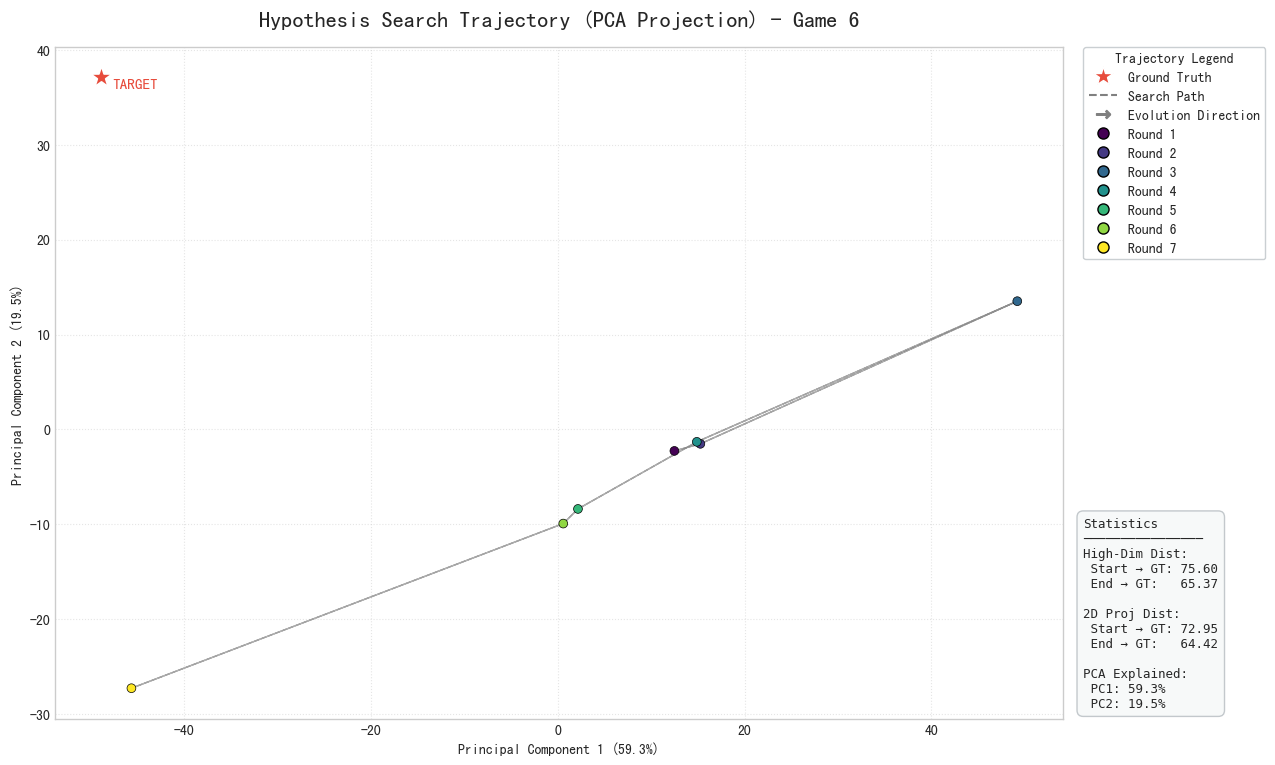

In [13]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D # 引入 Line2D 用于自定义图例

def plot_hypothesis_trajectory_pca(hist):
    """
    使用 PCA 将高维假设空间投影到 2D 平面，展示 Agent 内部模型逼近 Ground Truth 的轨迹
    (Layout Adjusted: 小点、无重叠文字、外部图例详细标注轮次)
    """
    internal_models = hist['internal_models'] # List of (N,)
    gt_vector = hist['gt_vector'] # (N,)
    rounds = hist['round']
    
    if len(internal_models) < 2:
        print("⚠️ 轮次太少，无法绘制轨迹 PCA。")
        return

    # 准备数据: [Model_R1, Model_R2, ..., Model_Rn, GT]
    # 将 GT 也放入并进行拟合，这样 component 包含了 GT 的特征方向
    data = np.vstack([internal_models, gt_vector.reshape(1, -1)])
    
    # PCA 降维
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(data)
    
    # 分离轨迹点和目标点
    traj_points = reduced_data[:-1]
    target_point = reduced_data[-1]
    
    # 颜色映射准备
    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(vmin=min(rounds), vmax=max(rounds))
    
    # 绘图 Setup
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 1. 绘制轨迹连线 (Search Path)
    # 使用虚线连接所有点
    ax.plot(traj_points[:, 0], traj_points[:, 1], '--', color='gray', alpha=0.3, linewidth=1.0)
    
    # 2. 绘制每一轮的点 (Small Dots)
    # s=60 -> 改为更小的 s=30 以避免重叠
    scatter = ax.scatter(traj_points[:, 0], traj_points[:, 1], c=rounds, cmap=cmap, norm=norm, s=40, zorder=5, edgecolors='k', linewidth=0.5)
    
    # 3. 绘制方向箭头 (清晰链接)
    for i in range(len(rounds) - 1):
        dx = traj_points[i+1, 0] - traj_points[i, 0]
        dy = traj_points[i+1, 1] - traj_points[i, 1]
        # 箭头从点 i 指向点 i+1
        # length_includes_head=True 确保箭头尖端在该位置结束
        # head_width 调整得稍微明显一点
        ax.arrow(traj_points[i, 0], traj_points[i, 1], dx, dy, 
                  head_width=0.04, head_length=0.06, fc='gray', ec='gray', alpha=0.6, 
                  length_includes_head=True, zorder=4)
            
    # 4. 绘制 Ground Truth (目标)
    ax.scatter(target_point[0], target_point[1], c='#E74C3C', marker='*', s=300, zorder=10, edgecolors='white', linewidth=1.5)
    ax.annotate("TARGET", (target_point[0], target_point[1]), 
                 xytext=(8, -8), textcoords='offset points', color='#E74C3C', fontweight='bold', fontsize=11)
    
    # 5. 计算距离 (2D & High-Dim)
    start_dist_2d = np.linalg.norm(traj_points[0] - target_point)
    end_dist_2d = np.linalg.norm(traj_points[-1] - target_point)
    start_dist_hd = np.linalg.norm(internal_models[0] - gt_vector)
    end_dist_hd = np.linalg.norm(internal_models[-1] - gt_vector)
    
    # 设置标题和标签
    ax.set_title(f"Hypothesis Search Trajectory (PCA Projection) - Game {GAME_ID}", fontsize=16, pad=15)
    ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, linestyle=':', alpha=0.5)

    # --- 关键修改: 构建自定义图例并移出图表区域 ---
    
    # 手动构建图例元素 handles
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#E74C3C', markersize=15, label='Ground Truth'),
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Search Path'),
        Line2D([0], [0], color='gray', marker=r'$\rightarrow$', markersize=10, linestyle='None', label='Evolution Direction')
    ]
    
    # 为每一轮添加一个颜色点到图例中
    for r in rounds:
        color = cmap(norm(r))
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, markeredgecolor='k', label=f'Round {r}'))

    # 放置图例 (放右侧上方外侧)
    # bbox_to_anchor=(1.02, 1) 紧邻右侧边缘
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., 
              title="Trajectory Legend", fontsize=10, frameon=True, edgecolor='#BDC3C7')

    # 统计信息文本 (放图例下方)
    info_text = (
        f"Statistics\n"
        f"────────────────\n"
        f"High-Dim Dist:\n"
        f" Start → GT: {start_dist_hd:.2f}\n"
        f" End → GT:   {end_dist_hd:.2f}\n\n"
        f"2D Proj Dist:\n"
        f" Start → GT: {start_dist_2d:.2f}\n"
        f" End → GT:   {end_dist_2d:.2f}\n\n"
        f"PCA Explained:\n"
        f" PC1: {pca.explained_variance_ratio_[0]:.1%}\n"
        f" PC2: {pca.explained_variance_ratio_[1]:.1%}"
    )
    
    # 放置统计信息文本框
    # y=0.3 大概在图例下方一段距离
    ax.text(1.02, 0.3, info_text, transform=ax.transAxes, fontsize=9, fontfamily='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#F7F9F9', edgecolor='#BDC3C7', alpha=0.9))

    # 调整布局，为右侧内容预留空间
    # right=0.8 表示 axes 只占画布宽度的 80%，剩下的 20% 给外侧元素
    plt.subplots_adjust(right=0.8, left=0.08, top=0.92, bottom=0.08)
    
    plt.show()

plot_hypothesis_trajectory_pca(history)

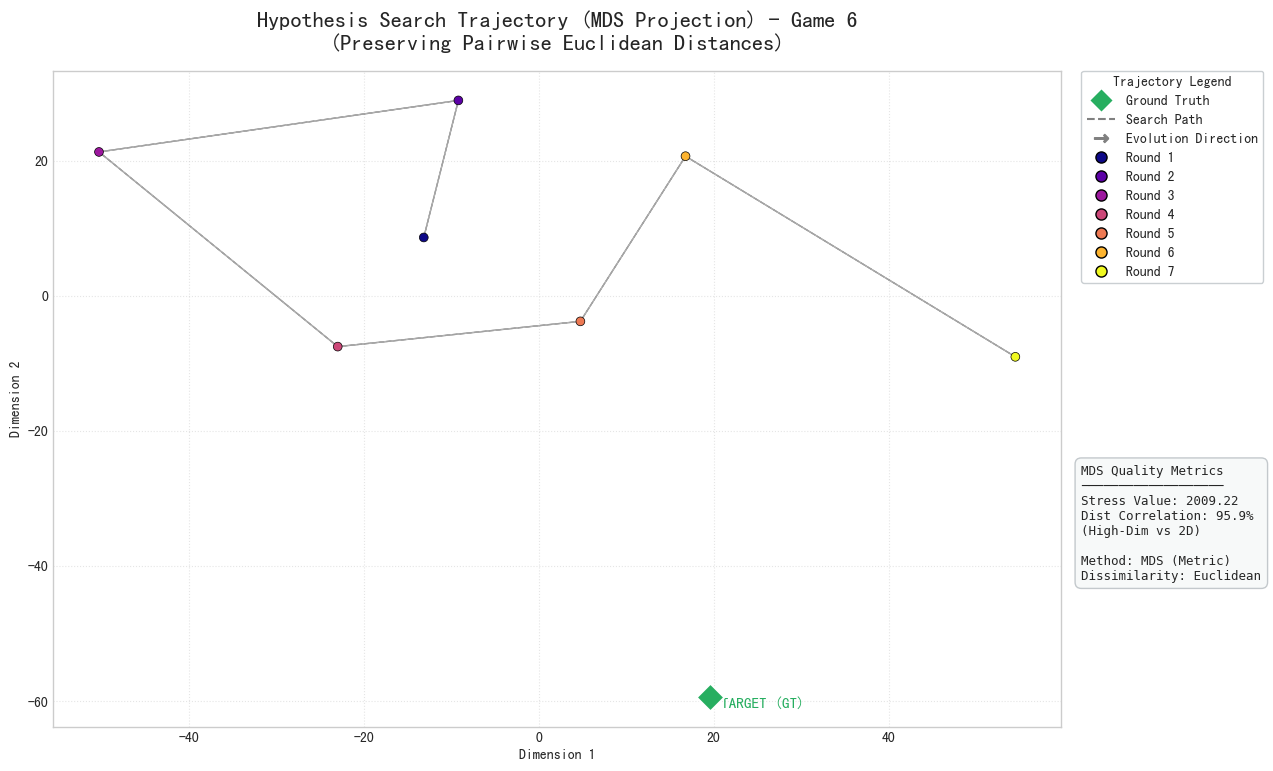

In [14]:
from sklearn.manifold import MDS

def plot_hypothesis_trajectory_mds(hist):
    """
    使用 MDS (多维缩放) 将高维假设空间投影到 2D 平面。
    优势：相比 PCA，MDS 更能真实保留样本点之间的距离关系 (Pairwise Distances)，
    这对于样本数少(N<10)但维度极高(D=5127)的情况更加稳健。
    """
    internal_models = hist['internal_models'] # List of (N,)
    gt_vector = hist['gt_vector'] # (N,)
    rounds = hist['round']
    
    if len(internal_models) < 2:
        return

    # 准备数据: [Model_R1, Model_R2, ..., Model_Rn, GT]
    data = np.vstack([internal_models, gt_vector.reshape(1, -1)])
    
    # MDS 降维 (使用欧氏距离作为dissimilarity)
    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42, normalized_stress='auto')
    reduced_data = mds.fit_transform(data)
    
    # 分离轨迹点和目标点
    traj_points = reduced_data[:-1]
    target_point = reduced_data[-1]
    
    # 颜色映射准备
    cmap = plt.get_cmap('plasma') # 换个颜色区分 PCA
    norm = plt.Normalize(vmin=min(rounds), vmax=max(rounds))
    
    # 绘图 Setup
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # 1. 绘制轨迹连线 (Search Path)
    ax.plot(traj_points[:, 0], traj_points[:, 1], '--', color='gray', alpha=0.3, linewidth=1.0)
    
    # 2. 绘制每一轮的点 (Small Dots)
    scatter = ax.scatter(traj_points[:, 0], traj_points[:, 1], c=rounds, cmap=cmap, norm=norm, s=40, zorder=5, edgecolors='k', linewidth=0.5)
    
    # 3. 绘制方向箭头
    for i in range(len(rounds) - 1):
        dx = traj_points[i+1, 0] - traj_points[i, 0]
        dy = traj_points[i+1, 1] - traj_points[i, 1]
        ax.arrow(traj_points[i, 0], traj_points[i, 1], dx, dy, 
                  head_width=0.05, head_length=0.08, fc='gray', ec='gray', alpha=0.6, 
                  length_includes_head=True, zorder=4)
            
    # 4. 绘制 Ground Truth (目标)
    ax.scatter(target_point[0], target_point[1], c='#27AE60', marker='D', s=200, zorder=10, edgecolors='white', linewidth=1.5)
    ax.annotate("TARGET (GT)", (target_point[0], target_point[1]), 
                 xytext=(8, -8), textcoords='offset points', color='#27AE60', fontweight='bold', fontsize=11)
    
    # 5. 计算 Stress (MDS 的拟合优度指标)
    stress = mds.stress_
    
    # 设置标题和标签
    ax.set_title(f"Hypothesis Search Trajectory (MDS Projection) - Game {GAME_ID}\n(Preserving Pairwise Euclidean Distances)", fontsize=16, pad=15)
    ax.set_xlabel(f"Dimension 1")
    ax.set_ylabel(f"Dimension 2")
    ax.grid(True, linestyle=':', alpha=0.5)

    # --- 自定义图例 ---
    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#27AE60', markersize=12, label='Ground Truth'),
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Search Path'),
        Line2D([0], [0], color='gray', marker=r'$\rightarrow$', markersize=10, linestyle='None', label='Evolution Direction')
    ]
    for r in rounds:
        color = cmap(norm(r))
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, markeredgecolor='k', label=f'Round {r}'))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., 
              title="Trajectory Legend", fontsize=10, frameon=True, edgecolor='#BDC3C7')

    # 统计信息文本
    # 计算高维和低维距离的相关性作为质量指标
    from scipy.stats import pearsonr
    from scipy.spatial.distance import pdist
    dist_high = pdist(data)
    dist_low = pdist(reduced_data)
    corr, _ = pearsonr(dist_high, dist_low)

    info_text = (
        f"MDS Quality Metrics\n"
        f"───────────────────\n"
        f"Stress Value: {stress:.2f}\n"
        f"Dist Correlation: {corr:.1%}\n"
        f"(High-Dim vs 2D)\n\n"
        f"Method: MDS (Metric)\n"
        f"Dissimilarity: Euclidean"
    )
    
    ax.text(1.02, 0.4, info_text, transform=ax.transAxes, fontsize=9, fontfamily='monospace',
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#F7F9F9', edgecolor='#BDC3C7', alpha=0.9))

    plt.subplots_adjust(right=0.8, left=0.08, top=0.90, bottom=0.08)
    plt.show()

plot_hypothesis_trajectory_mds(history)